# Tratamento dos dados

## Une as tabelas

In [94]:
import pandas as pd

# Ler os arquivos CSV
articles_df = pd.read_csv('articles.csv')
data_extraction_df = pd.read_csv('data_extraction.csv')

outputCsv = 'merged_articles_data.csv'

# Renomear colunas para facilitar o merge
data_extraction_df = data_extraction_df.rename(columns={'article': 'title'})

# Converter colunas de data para datetime (se necessário)
articles_df['year'] = pd.to_numeric(articles_df['year'], errors='coerce')
data_extraction_df['Ano'] = pd.to_numeric(data_extraction_df['Ano'], errors='coerce')

# Fazer o merge dos dataframes
merged_df = pd.merge(
    articles_df,  # Colunas que queremos do articles.csv
    data_extraction_df,
    on='title',
    how='outer'
)

# Preencher anos faltantes: usar o ano do data_extraction quando não houver no articles
merged_df['year'] = merged_df['year'].fillna(merged_df['Ano'])

# Remover a coluna Ano auxiliar
merged_df = merged_df.drop(columns=['Ano'])

# Renomear coluna year para ano para manter consistência
merged_df = merged_df.rename(columns={'year': 'ano'})

# Reordenar colunas (opcional)
cols = ['title', 'ano'] + [col for col in merged_df.columns if col not in ['title', 'ano']]
merged_df = merged_df[cols]

# Salvar o resultado em um novo arquivo CSV
merged_df.to_csv(outputCsv, index=False)

print("Arquivo criado com sucesso!")
print(f"Total de registros: {len(merged_df)}")

Arquivo criado com sucesso!
Total de registros: 1515


## Corrige termos

In [95]:
import pandas as pd

inputCsv = 'merged_articles_data.csv'
outputCsv = 'transformed_data.csv'

# Dicionário de traduções
translation_dict = {
    # Tecnologias de Display
    'Embutido': 'Embedded',
    'Projetor superior': 'Front-Projected',
    'Projetor inferior': 'Rear-Projected',

    # Tecnologias de Input
    'Caneta': 'Pen',
    'Ondas sonoras': 'Sound-Based',
    'Sensor infravermelho': 'Sensor-Assisted-Vision-Based',
    'Tokens tangíveis': 'Tangible-Tokens',
    'Toque': 'Electrical-Based',
    'Visão computacional': 'Vision-Based',

    # Critérios de seleção
    'Incomplete works, posters, summaries': 'Incomplete works, posters, summaries, etc',
    'Interfaces with only mouse/keyboard interaction': 'Interfaces without direct interaction',
    'The digital tabletop interface was not tangible': 'Study was not about digital tabletops',
}

def translate_terms(text):
    if pd.isna(text):
        return text
    for pt, en in translation_dict.items():
        text = text.replace(pt, en)
    return text

# Carregar os dados (substitua pelo seu arquivo real)
df = pd.read_csv(inputCsv)

# Aplicar traduções nas colunas relevantes
df['Tecnologia do display'] = df['Tecnologia do display'].apply(translate_terms)
df['Tecnologia do input'] = df['Tecnologia do input'].apply(translate_terms)
df['selection_criteria'] = df['selection_criteria'].apply(translate_terms)

# Salvar o resultado (substitua pelo nome desejado)
df.to_csv(outputCsv, index=False)

print("Transformação concluída! Resultado salvo em " + outputCsv)
print("\nAmostra dos dados transformados:")
print(df.head())

Transformação concluída! Resultado salvo em transformed_data.csv

Amostra dos dados transformados:
                                               title   ano  \
0  "All in the Same Boat": Tradeoffs of Voice Ass...  2020   
1  "Callout Bubble Saved My Life": Workspace Awar...  2015   
2  "Dinner Party" sociable interfaces in a tablet...  2011   
3  "Local Remote" Collaboration: Applying Remote ...  2015   
4                   1.24 - Augmented Reality and GIS  2018   

                source                                 selection_criteria  \
0  ACM Digital Library              Study was not about digital tabletops   
1  ACM Digital Library              Study was not about digital tabletops   
2  ACM Digital Library  Study describing digital tabletop application ...   
3  ACM Digital Library          Incomplete works, posters, summaries, etc   
4       Science@Direct         Articles that omits the tabletop technique   

     status comments Tecnologia do display  \
0  Rejected      Na

# Gráficos

## Artigos aceitos por ano

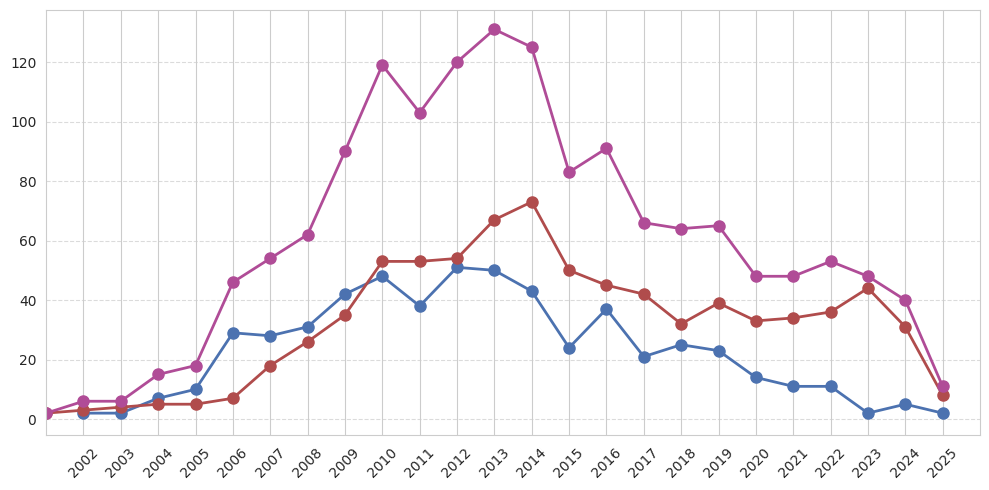

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar os dados
articles_df = pd.read_csv('articles.csv')

# Filtrar apenas artigos "Accepted" e contar por ano
accepted_per_year = articles_df[articles_df['status'] == 'Accepted']['year'].value_counts().sort_index()

rejected_per_year = articles_df[articles_df['status'] == 'Rejected']['year'].value_counts().sort_index()

articles_per_year = articles_df['year'].value_counts().sort_index()

# Configurar o gráfico
plt.figure(figsize=(10, 5))
accepted_per_year.plot(
    marker='o',
    linestyle='-',
    color='#4C72B0',
    linewidth=2,
    markersize=8
)

rejected_per_year.plot(
    marker='o',
    linestyle='-',
    color="#B04C4C",
    linewidth=2,
    markersize=8
)

articles_per_year.plot(
    marker='o',
    linestyle='-',
    color="#B04C97",
    linewidth=2,
    markersize=8    
)


# Adicionar rótulos e título
plt.title('', fontsize=14, pad=20)
plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajustar eixos para mostrar apenas anos com dados
plt.xticks(accepted_per_year.index, rotation=45)
plt.xlim(accepted_per_year.index.min() - 1, accepted_per_year.index.max() + 1)

plt.tight_layout()
plt.savefig('accepted_per_year.png', dpi=300)
plt.show()

## Razões de aceite/rejeite

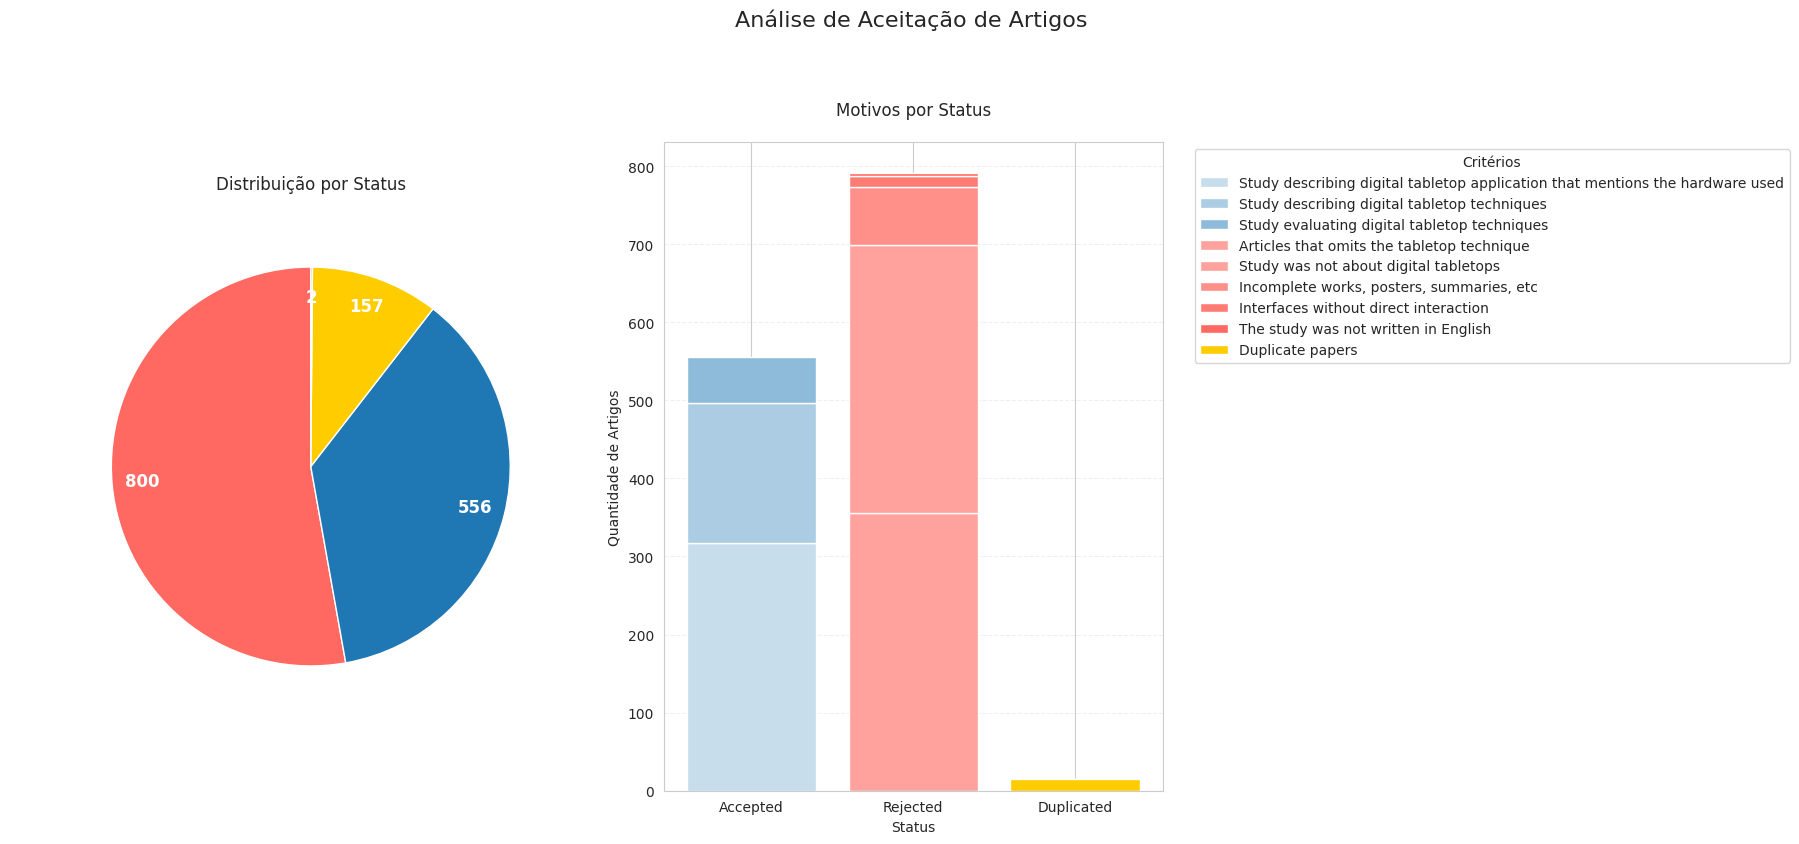

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from matplotlib.patches import Patch

# Carregar os dados
articles_df = pd.read_csv('transformed_data.csv')

# 1. Contar status
status_counts = articles_df['status'].value_counts()

# 2. Análise dos critérios de seleção para subdivisão
criteria_analysis = defaultdict(dict)

for status in ['Accepted', 'Rejected', 'Duplicated']:
    subset = articles_df[articles_df['status'] == status]
    criteria_counts = subset['selection_criteria'].value_counts()
    for criteria, count in criteria_counts.items():
        if pd.notna(criteria):  # Ignorar valores NaN
            criteria_analysis[status][criteria] = count

# Criar DataFrame a partir da análise
criteria_df = pd.DataFrame.from_dict(criteria_analysis, orient='index').fillna(0)

# 3. Criar figura com subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Análise de Aceitação de Artigos', fontsize=16, y=1.05)

# Função para obter a cor do status
def get_status_color(status):
    return {
        'Accepted': '#1f77b4',  # Azul
        'Rejected': '#ff6961',  # Vermelho
        'Duplicated': '#ffcc00'  # Amarelo
    }.get(status, '#999999')  # Cinza para outros status

# Gráfico de pizza principal (Status)
wedges, texts, autotexts = ax1.pie(
    status_counts,
    labels=status_counts.index,
    colors=[get_status_color(s) for s in status_counts.index],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1},
    autopct=lambda p: f'{int(p * sum(status_counts)/100)}',
    pctdistance=0.85,
    textprops={'fontsize': 12, 'color': 'white', 'weight': 'bold'}
)

ax1.set_title('Distribuição por Status', pad=20)

# Configuração de cores para os critérios
def generate_color_palette(base_color, n_colors):
    """Gera n tons de uma cor base"""
    from matplotlib.colors import LinearSegmentedColormap
    cmap = LinearSegmentedColormap.from_list('custom', ['white', base_color], N=n_colors)
    return [cmap(i) for i in np.linspace(0.3, 1, n_colors)]

# Número de critérios únicos
all_criteria = criteria_df.columns.tolist()
n_criteria = len(all_criteria)

# Gerar paleta para cada status
status_palettes = {
    status: generate_color_palette(get_status_color(status), n_criteria)
    for status in criteria_df.index
}

# Plotar gráfico de barras empilhadas
x = np.arange(len(criteria_df.index))  # Posições das barras
width = 0.8  # Largura das barras
bottom = np.zeros(len(criteria_df.index))  # Inicializar valores base

# Primeiro criar um dicionário de legendas
legend_elements = []

# Plotar as barras e coletar cores usadas
bar_plots = []  # Para armazenar os objetos de barra
legend_colors = {}  # Para mapear critério -> cor usada

# Plotar as barras
for j, criteria in enumerate(all_criteria):
    heights = criteria_df[criteria].values
    
    for i, status in enumerate(criteria_df.index):
        if heights[i] > 0:
            # Armazena a cor usada para este critério (usamos a cor do primeiro status que o contém)
            if criteria not in legend_colors:
                legend_colors[criteria] = status_palettes[status][j]
            
            bar = ax2.bar(
                x[i],
                heights[i],
                width,
                bottom=bottom[i],
                color=status_palettes[status][j],
                edgecolor='white',
                label=criteria if criteria not in legend_colors else ""
            )
            bar_plots.append(bar)
    
    bottom += heights

legend_elements = [
    Patch(facecolor=legend_colors[criteria], 
          edgecolor='white', 
          label=criteria)
    for criteria in all_criteria
]

# Configurar eixo x
ax2.set_xticks(x)
ax2.set_xticklabels(criteria_df.index)
ax2.set_title('Motivos por Status', pad=20)
ax2.set_ylabel('Quantidade de Artigos')
ax2.set_xlabel('Status')
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# Adicionar legenda completa
ax2.legend(handles=legend_elements, 
           title='Critérios', 
           bbox_to_anchor=(1.05, 1), 
           loc='upper left')

# Ajustar layout
plt.tight_layout()
plt.savefig('enhanced_acceptance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## Tecnologias de Display por ano

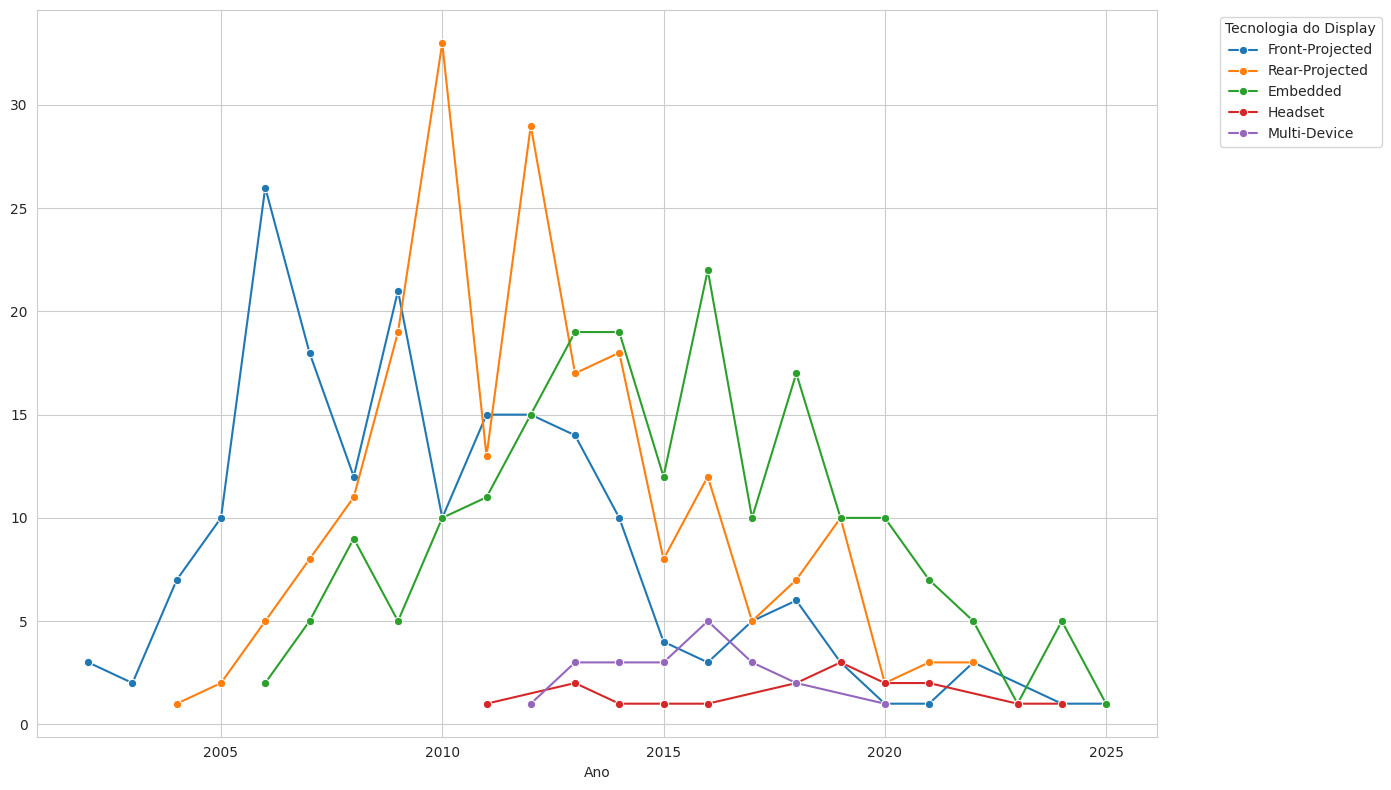

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar os dados
df = pd.read_csv("transformed_data.csv")
    
# Remover linhas com ano ou tecnologia do display ausente
df = df.dropna(subset=["ano", "Tecnologia do display"])

# Converter ano para inteiro
df["ano"] = df["ano"].astype(int)

# Separar as técnicas de display por vírgula e remover espaços em excesso
df["Tecnologia do display"] = df["Tecnologia do display"].str.split(",")

# Explodir as linhas com múltiplas técnicas em linhas separadas
df = df.explode("Tecnologia do display")

# Remover espaços em branco extras
df["Tecnologia do display"] = df["Tecnologia do display"].str.strip()

# Contar quantas vezes cada técnica aparece por ano
timeline = df.groupby(["ano", "Tecnologia do display"]).size().reset_index(name="count")

# Plotar o gráfico
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
sns.lineplot(data=timeline, x="ano", y="count", hue="Tecnologia do display", marker="o")

# Ajustes finais
plt.title("", fontsize=16)
plt.xlabel("Ano")
plt.ylabel("")
plt.legend(title="Tecnologia do Display", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Output por ano

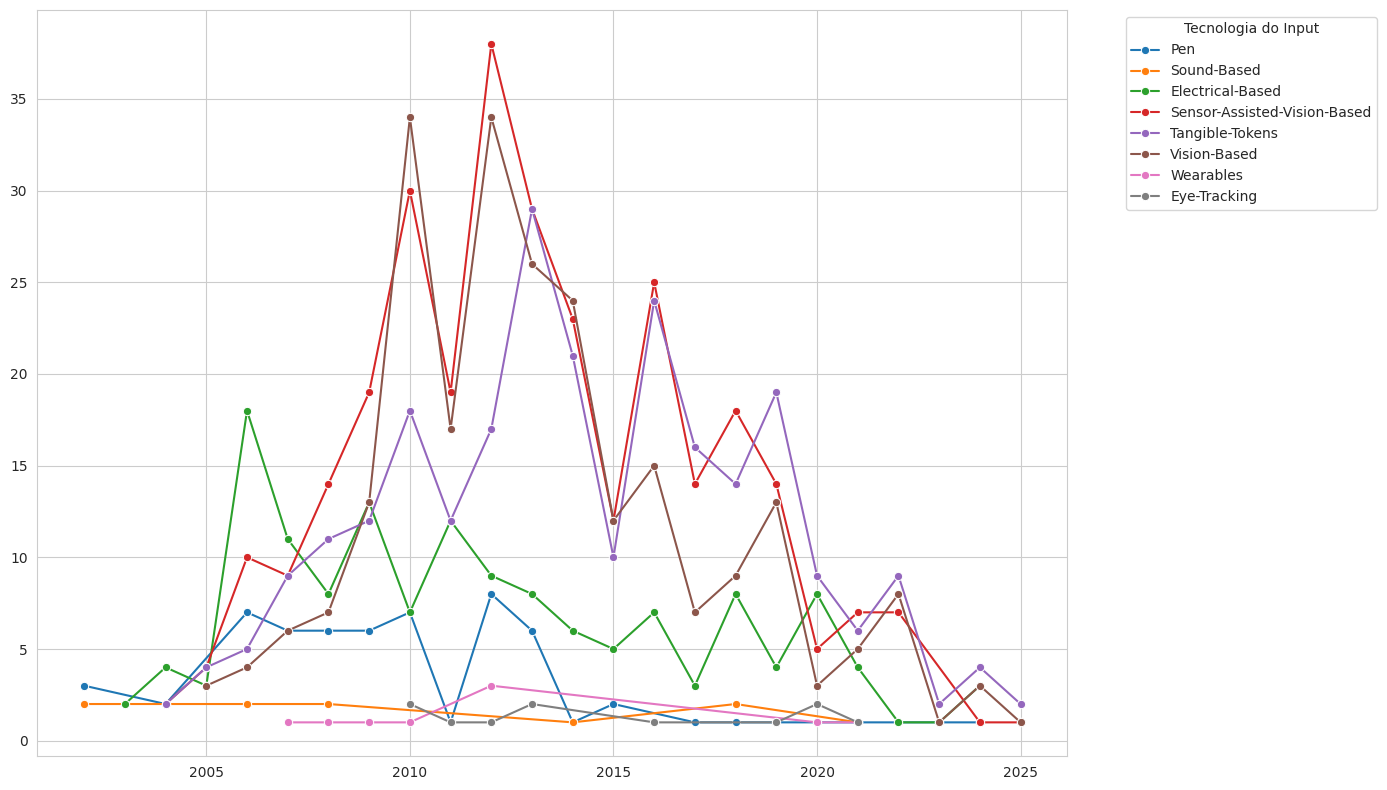

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar os dados
df = pd.read_csv("transformed_data.csv")

# Remover linhas com ano ou tecnologia do input ausente
df = df.dropna(subset=["ano", "Tecnologia do input"])

# Converter ano para inteiro
df["ano"] = df["ano"].astype(int)

# Separar as técnicas de input por vírgula e limpar espaços
df["Tecnologia do input"] = df["Tecnologia do input"].str.split(",")

# Explodir listas em linhas separadas
df = df.explode("Tecnologia do input")

# Remover espaços em branco extras
df["Tecnologia do input"] = df["Tecnologia do input"].str.strip()

# Contar ocorrências por ano e técnica
timeline_input = df.groupby(["ano", "Tecnologia do input"]).size().reset_index(name="count")

# Plotar
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
sns.lineplot(data=timeline_input, x="ano", y="count", hue="Tecnologia do input", marker="o")

# Ajustes finais
plt.title("", fontsize=16)
plt.xlabel("")
plt.ylabel("")
plt.legend(title="Tecnologia do Input", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Maior tamanho encontrado: 169


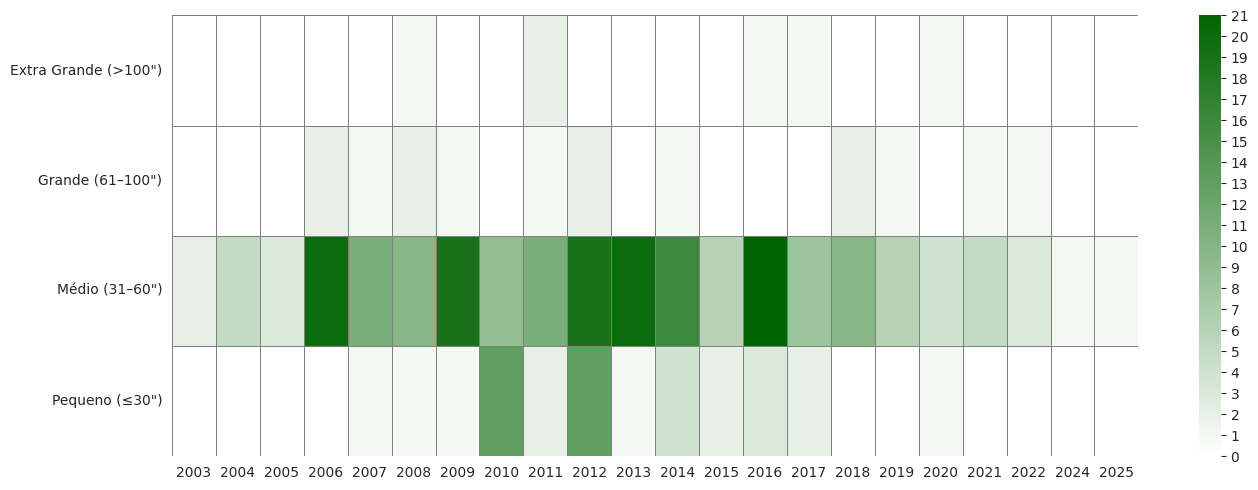

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Carregar e limpar dados
df = pd.read_csv("transformed_data.csv")
df = df.dropna(subset=["ano", "Tamanho da mesa"])
df["ano"] = df["ano"].astype(int)
df["Tamanho da mesa"] = df["Tamanho da mesa"].str.replace(r'["”’’″]', '', regex=True).str.strip()
df["Tamanho da mesa"] = pd.to_numeric(df["Tamanho da mesa"])
df = df.dropna(subset=["Tamanho da mesa"])

# Arredondar para inteiro
df["Tamanho da mesa"] = df["Tamanho da mesa"].round(0).astype(int)

# Mostrar o maior valor
print("Maior tamanho encontrado:", df["Tamanho da mesa"].max())

# Criar faixas de tamanho
def categorizar_tamanho(t):
    if t <= 30:
        return "Pequeno (≤30\")"
    elif t <= 60:
        return "Médio (31–60\")"
    elif t <= 100:
        return "Grande (61–100\")"
    else:
        return "Extra Grande (>100\")"

df["Faixa de Tamanho"] = df["Tamanho da mesa"].apply(categorizar_tamanho)

# Agrupar por faixa e ano
faixa_heatmap = df.groupby(["Faixa de Tamanho", "ano"]).size().unstack(fill_value=0)

# Manter a ordem das faixas
faixa_order = ["Extra Grande (>100\")", "Grande (61–100\")", "Médio (31–60\")", "Pequeno (≤30\")"]
faixa_heatmap = faixa_heatmap.reindex(index=faixa_order, columns=todos_os_anos, fill_value=0)

cmap_branco_verde = LinearSegmentedColormap.from_list("branco_verde", ["#ffffff", "#006400"])

# Plotar heatmap por faixas
plt.figure(figsize=(14, 5))
ax2 = sns.heatmap(
    faixa_heatmap,
    cmap=cmap_branco_verde,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"ticks": np.arange(0, faixa_heatmap.values.max() + 1)},
)
ax2.collections[0].colorbar.set_ticks(np.arange(0, faixa_heatmap.values.max() + 1))
plt.title("", fontsize=16)
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()



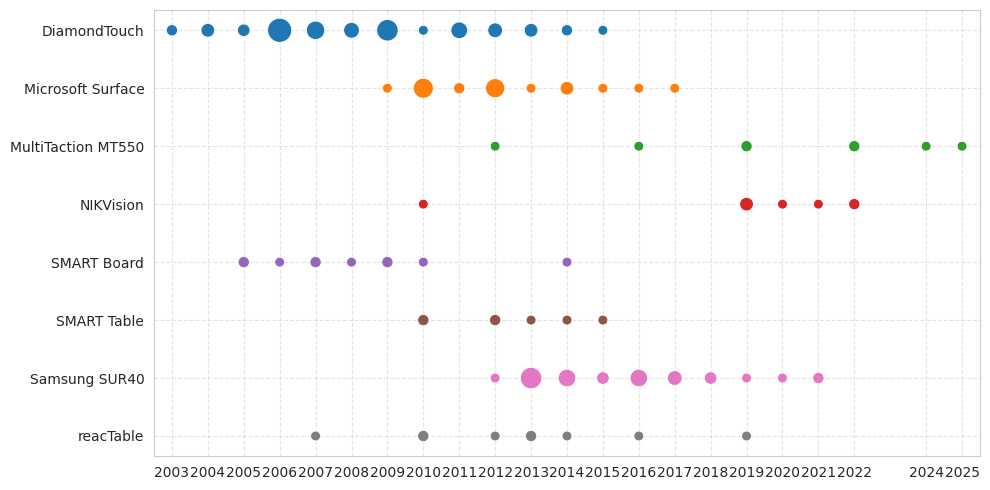

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar dados
df = pd.read_csv("transformed_data.csv")

# Limpar a coluna de ano
df["ano"] = pd.to_numeric(df["ano"], errors="coerce").dropna().astype(int)

# Filtrar onde há modelos com nome
df_modelos = df.dropna(subset=["Usa modelo com nome?"]).copy()

# Normalizar: manter só o nome antes do '+' (ex: "DiamondTouch + Pen" -> "DiamondTouch")
df_modelos["Usa modelo com nome?"] = (
    df_modelos["Usa modelo com nome?"]
    .str.split("+", n=1)
    .str[0]
    .str.strip()
)

# Contagem por modelo e ano
modelo_por_ano = df_modelos.groupby(["Usa modelo com nome?", "ano"]).size().reset_index(name="count")

# Contar total de ocorrências por modelo
modelo_total = modelo_por_ano.groupby("Usa modelo com nome?")["count"].sum()

# Manter apenas modelos com mais de 5 ocorrências no total
modelos_filtrados = modelo_total[modelo_total > 5].index

# Filtrar os dados
modelo_por_ano_filtrado = modelo_por_ano[modelo_por_ano["Usa modelo com nome?"].isin(modelos_filtrados)]

# Plotar
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=modelo_por_ano_filtrado,
    x="ano",
    y="Usa modelo com nome?",
    size="count",
    hue="Usa modelo com nome?",
    legend=False,
    sizes=(50, 300),
)

plt.title("", fontsize=16)
plt.xlabel("")
plt.ylabel("")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.xticks(sorted(modelo_por_ano_filtrado["ano"].unique()))  # Mostrar apenas os anos existentes
plt.xlim(
    modelo_por_ano_filtrado["ano"].min() - 0.5,
    modelo_por_ano_filtrado["ano"].max() + 0.5
)
plt.show()
